1. ¿Qué categorías generan el mayor ingreso y cuáles deberían recibir mayor inversión?

Objetivo gerencial: Priorizar presupuesto comercial e inventario.

Variables involucradas:

* categoria
* precio
* cantidad

KPIs esperados:

* Ingreso total
* Participación porcentual
* Unidades vendidas
* Ticket promedio

Python que practicarás:

* groupby()
* columnas calculadas (ventas = precio * cantidad)
* sort_values()
* gráficos de barras

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv(
    "ventas_bogota_limpiar.csv",
    sep=";",
    encoding="utf-8"
)

             Ingreso total  Participación (%)  Unidades vendidas  \
categoria                                                          
Accesorios    5.482465e+08          33.337663                320   
Electrónica   5.329718e+08          32.408844                318   
Periféricos   5.633076e+08          34.253493                346   

             Ticket promedio  
categoria                     
Accesorios      8.434562e+06  
Electrónica     9.189170e+06  
Periféricos     8.407576e+06  


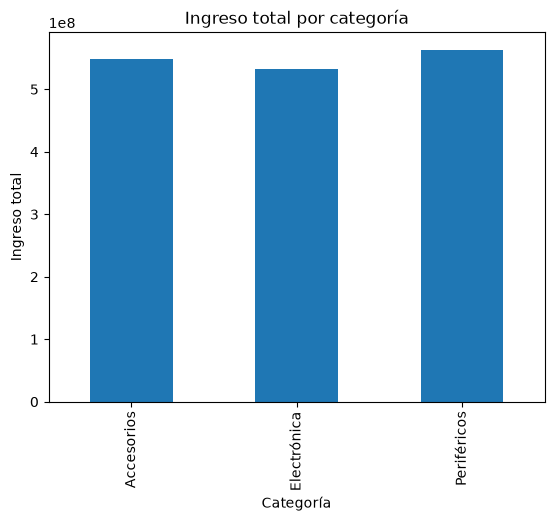

In [8]:
# 1. Crear la columna venta_total
# Multiplicamos el precio por la cantidad vendida

df["venta_total"] = df["precio"] * df["cantidad"]


# 2. Calcular el ingreso total por categoría
# Agrupamos por categoria y sumamos las ventas
ingreso_categoria = (
    df.groupby("categoria")["venta_total"]
    .sum()
    .sort_values(ascending=False)
)


# 3. Calcular las unidades vendidas por categoría
# Agrupamos por categoria y sumamos la cantidad
unidades_categoria = (
    df.groupby("categoria")["cantidad"]
    .sum()
    .sort_values(ascending=False)
)


# 4. Calcular el ingreso promedio por venta (ticket promedio)
# Agrupamos por categoria y calculamos el promedio de venta_total
ticket_promedio = (
    df.groupby("categoria")["venta_total"]
    .mean()
    .sort_values(ascending=False)
)


# 5. Calcular la participación porcentual de cada categoría
# Dividimos el ingreso de cada categoría entre el ingreso total
participacion = (
    ingreso_categoria / ingreso_categoria.sum() * 100
)


# 6. Crear una tabla resumen con todos los KPIs
resumen = pd.DataFrame({
    "Ingreso total": ingreso_categoria,
    "Participación (%)": participacion,
    "Unidades vendidas": unidades_categoria,
    "Ticket promedio": ticket_promedio
})


# 7. Mostrar la tabla resumen
print(resumen)


# 8. Crear un gráfico de barras del ingreso por categoría
resumen["Ingreso total"].plot(kind="bar")

# 9. Agregar título
plt.title("Ingreso total por categoría")

# 10. Agregar nombre al eje X
plt.xlabel("Categoría")

# 11. Agregar nombre al eje Y
plt.ylabel("Ingreso total")

# 12. Mostrar el gráfico
plt.show()

2. ¿En qué ciudades estamos vendiendo mejor y dónde existen oportunidades de crecimiento?

Objetivo gerencial: Definir estrategia regional y asignación de recursos.

Variables:

* ciudad
* precio
* cantidad

KPIs:

* Ventas por ciudad
* Número de transacciones
* Ingreso promedio por venta
* Ranking de ciudades

Valor para la dirección:
Una ciudad puede tener muchas ventas pero poco ingreso, mientras otra puede tener pocas ventas con alto valor económico.

VENTAS TOTALES POR CIUDAD
ciudad
bogotá          3.070238e+08
Barranquilla    2.662134e+08
Bogotá          2.585035e+08
Medellín        2.453065e+08
Cali            2.393811e+08
BOGOTA          2.204898e+08
Name: venta_total, dtype: float64

NÚMERO DE TRANSACCIONES POR CIUDAD
ciudad
bogotá          38
Cali            35
Barranquilla    33
BOGOTA          32
Bogotá          30
Medellín        28
dtype: int64

INGRESO PROMEDIO POR VENTA
ciudad
bogotá          9.030113e+06
Bogotá          8.913912e+06
Barranquilla    8.873779e+06
Medellín        8.760947e+06
BOGOTA          7.603095e+06
Cali            7.480660e+06
Name: venta_total, dtype: float64

RESUMEN POR CIUDAD
              Ventas totales  Número de transacciones  Ingreso promedio
ciudad                                                                 
BOGOTA          2.204898e+08                       32      7.603095e+06
Barranquilla    2.662134e+08                       33      8.873779e+06
Bogotá          2.585035e+08          

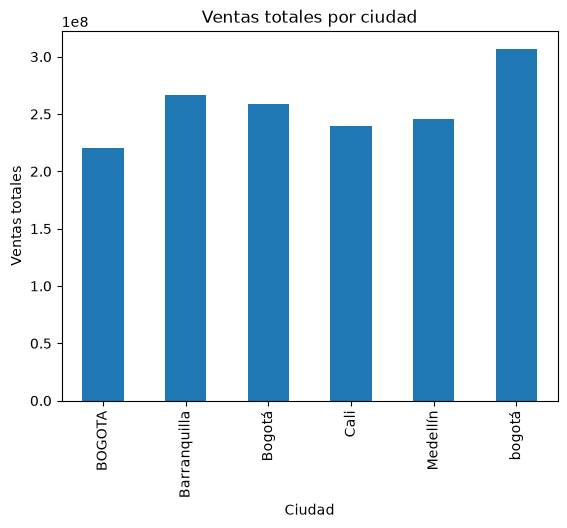

In [10]:
# ============================================================
# PUNTO 2 - VENTAS POR CIUDAD
# ¿En qué ciudades estamos vendiendo mejor
# y dónde existen oportunidades de crecimiento?
# ============================================================


# 1. IMPORTAR LAS LIBRERÍAS
import pandas as pd
import matplotlib.pyplot as plt


# 2. CARGAR EL ARCHIVO CSV
df = pd.read_csv(
    "ventas_bogota_limpiar.csv",
    sep=";",
    encoding="utf-8"
)


# 3. LIMPIAR LOS NOMBRES DE LAS COLUMNAS
df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)


# 4. CREAR LA COLUMNA VENTA TOTAL
# Precio × cantidad = venta total
df["venta_total"] = df["precio"] * df["cantidad"]


# 5. VENTAS TOTALES POR CIUDAD
# Agrupamos por ciudad y sumamos las ventas
ventas_ciudad = (
    df.groupby("ciudad")["venta_total"]
    .sum()
    .sort_values(ascending=False)
)

print("VENTAS TOTALES POR CIUDAD")
print(ventas_ciudad)


# 6. NÚMERO DE TRANSACCIONES POR CIUDAD
# Contamos cuántas ventas existen en cada ciudad
transacciones_ciudad = (
    df.groupby("ciudad")
    .size()
    .sort_values(ascending=False)
)

print("\nNÚMERO DE TRANSACCIONES POR CIUDAD")
print(transacciones_ciudad)


# 7. INGRESO PROMEDIO POR VENTA
# Calculamos el promedio de venta de cada ciudad
promedio_ciudad = (
    df.groupby("ciudad")["venta_total"]
    .mean()
    .sort_values(ascending=False)
)

print("\nINGRESO PROMEDIO POR VENTA")
print(promedio_ciudad)


# 8. CREAR UNA TABLA RESUMEN
resumen_ciudad = pd.DataFrame({
    "Ventas totales": ventas_ciudad,
    "Número de transacciones": transacciones_ciudad,
    "Ingreso promedio": promedio_ciudad
})


# 9. MOSTRAR LA TABLA RESUMEN
print("\nRESUMEN POR CIUDAD")
print(resumen_ciudad)


# 10. GRÁFICO DE VENTAS TOTALES POR CIUDAD
resumen_ciudad["Ventas totales"].plot(kind="bar")

plt.title("Ventas totales por ciudad")
plt.xlabel("Ciudad")
plt.ylabel("Ventas totales")

plt.show()

3. ¿Qué productos generan alto volumen, pero baja rentabilidad potencial?

Objetivo gerencial: Optimizar el portafolio de productos.

Variables:

* producto
* precio
* cantidad

Análisis esperado:

* Top productos por ingresos
* Top por unidades
* Matriz Volumen vs Valor

Insight de negocio:
Identificar productos “estrella” y productos que venden mucho, pero aportan poco valor económico.

TOP PRODUCTOS POR INGRESOS
producto
Laptop       3.956426e+08
Teclado      3.538768e+08
Monitor      3.252636e+08
Audífonos    3.183823e+08
Mouse        2.513606e+08
Name: venta_total, dtype: float64

TOP PRODUCTOS POR UNIDADES
producto
Monitor      234
Laptop       205
Audífonos    199
Teclado      190
Mouse        156
Name: cantidad, dtype: int64

RESUMEN DE PRODUCTOS
           Ingresos totales  Unidades vendidas
producto                                      
Audífonos      3.183823e+08                199
Laptop         3.956426e+08                205
Monitor        3.252636e+08                234
Mouse          2.513606e+08                156
Teclado        3.538768e+08                190


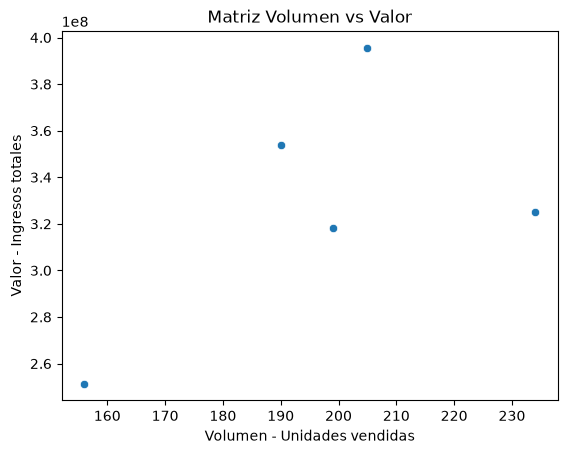

In [11]:

# 1. CREAR LA VENTA TOTAL
# Precio × cantidad = ingreso de cada venta

df["venta_total"] = df["precio"] * df["cantidad"]


# 2. TOP PRODUCTOS POR INGRESOS
# Agrupamos por producto y sumamos el ingreso

ingreso_producto = (
    df.groupby("producto")["venta_total"]
    .sum()
    .sort_values(ascending=False)
)

print("TOP PRODUCTOS POR INGRESOS")
print(ingreso_producto)


# 3. TOP PRODUCTOS POR UNIDADES
# Agrupamos por producto y sumamos las unidades vendidas

unidades_producto = (
    df.groupby("producto")["cantidad"]
    .sum()
    .sort_values(ascending=False)
)

print("\nTOP PRODUCTOS POR UNIDADES")
print(unidades_producto)


# 4. CREAR TABLA RESUMEN

resumen_producto = pd.DataFrame({
    "Ingresos totales": ingreso_producto,
    "Unidades vendidas": unidades_producto
})

print("\nRESUMEN DE PRODUCTOS")
print(resumen_producto)


# 5. MATRIZ VOLUMEN VS VALOR
# Cada punto representa un producto
# X = unidades vendidas
# Y = ingresos totales

sns.scatterplot(
    data=resumen_producto,
    x="Unidades vendidas",
    y="Ingresos totales"
)

plt.title("Matriz Volumen vs Valor")
plt.xlabel("Volumen - Unidades vendidas")
plt.ylabel("Valor - Ingresos totales")

plt.show()

4. ¿Existe relación entre el método de pago y la satisfacción del cliente?

Objetivo gerencial: Mejorar la experiencia de compra.

Variables:

* metodo_pago
* cliente_satisfecho

KPIs:

* % de clientes satisfechos por método
* Cantidad de respuestas positivas y negativas
* Ranking de métodos

Python que practicarás:

* limpieza de texto (str.lower(), strip())
* tablas dinámicas (pivot_table)
* porcentajes
* heatmaps o barras apiladas

Posible decisión:
Si un método presenta menor satisfacción, revisar tiempos de aprobación o procesos de pago.

Métodos de pago:
<StringArray>
['Tarjeta', nan, 'Efectivo', 'tarjeta', 'Transferencia']
Length: 5, dtype: str

Valores de satisfacción:
<StringArray>
['si', 'No', nan, 'Sí', 'NO']
Length: 5, dtype: str

SATISFACCIÓN POR MÉTODO DE PAGO
cliente_satisfecho  NO  No  Sí  si
metodo_pago                       
Efectivo             4  11  10  11
Tarjeta              4   9  13  11
Transferencia        9   8   9   6
tarjeta              7   3   6   8

PORCENTAJE DE SATISFACCIÓN
cliente_satisfecho         NO         No         Sí         si
metodo_pago                                                   
Efectivo            11.111111  30.555556  27.777778  30.555556
Tarjeta             10.810811  24.324324  35.135135  29.729730
Transferencia       28.125000  25.000000  28.125000  18.750000
tarjeta             29.166667  12.500000  25.000000  33.333333

PORCENTAJE DE CLIENTES SATISFECHOS POR MÉTODO
metodo_pago
Tarjeta          35.135135
Transferencia    28.125000
Efectivo         27.777778
tarjeta  

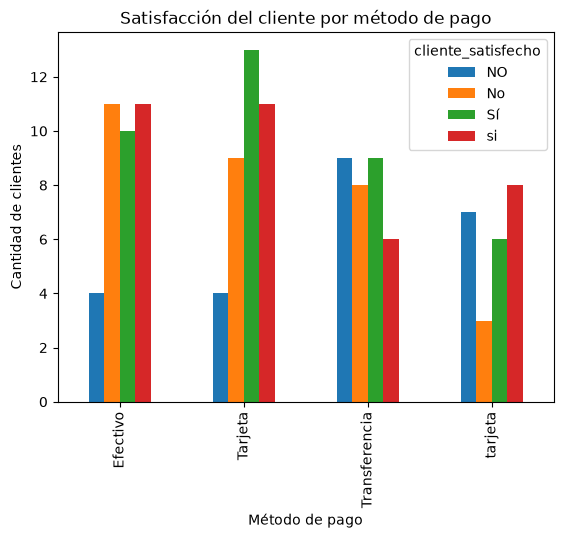

In [12]:
# ¿Existe relación entre el método de pago
# y la satisfacción del cliente?
# ============================================================


# 1. REVISAR LOS VALORES DE LAS COLUMNAS

print("Métodos de pago:")
print(df["metodo_pago"].unique())

print("\nValores de satisfacción:")
print(df["cliente_satisfecho"].unique())


# 2. CREAR TABLA CRUZADA
# Cruza método de pago con satisfacción

satisfaccion = pd.crosstab(
    df["metodo_pago"],
    df["cliente_satisfecho"]
)

print("\nSATISFACCIÓN POR MÉTODO DE PAGO")
print(satisfaccion)


# 3. CALCULAR PORCENTAJES
# normalize="index" calcula el porcentaje
# dentro de cada método de pago

porcentaje_satisfecho = (
    pd.crosstab(
        df["metodo_pago"],
        df["cliente_satisfecho"],
        normalize="index"
    ) * 100
)

print("\nPORCENTAJE DE SATISFACCIÓN")
print(porcentaje_satisfecho)


# 4. OBTENER EL PORCENTAJE DE CLIENTES SATISFECHOS

satisfechos = (
    porcentaje_satisfecho["Sí"]
    .sort_values(ascending=False)
)

print("\nPORCENTAJE DE CLIENTES SATISFECHOS POR MÉTODO")
print(satisfechos)


# 5. CREAR RANKING

ranking = satisfechos.sort_values(ascending=False)

print("\nRANKING DE MÉTODOS DE PAGO")
print(ranking)


# 6. CREAR GRÁFICO

satisfaccion.plot(
    kind="bar"
)

plt.title("Satisfacción del cliente por método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Cantidad de clientes")

plt.show()

5. ¿Cómo evolucionaron las ventas entre enero y junio de 2024?

Objetivo gerencial: Detectar tendencias y planificar demanda.

Variables:

* fecha
* precio
* cantidad

KPIs:

* Ventas mensuales
* Crecimiento mes a mes
* Unidades vendidas
* Variación porcentual

Python que practicarás:

* to_datetime()
* extracción de mes
* groupby() temporal
* gráficos de línea
* cálculo de crecimiento (%)

VENTAS MENSUALES
mes
2024-01    2.288759e+08
2024-02    3.158388e+08
2024-03    2.173025e+08
2024-04    3.775833e+08
2024-05    3.227376e+08
2024-06    1.821877e+08
Freq: M, Name: venta_total, dtype: float64

UNIDADES VENDIDAS
mes
2024-01    118
2024-02    173
2024-03    155
2024-04    227
2024-05    198
2024-06    113
Freq: M, Name: cantidad, dtype: int64

CRECIMIENTO MES A MES (%)
mes
2024-01          NaN
2024-02    37.995644
2024-03   -31.198276
2024-04    73.759257
2024-05   -14.525455
2024-06   -43.549275
Freq: M, Name: venta_total, dtype: float64

RESUMEN MENSUAL
         Ventas mensuales  Unidades vendidas  Crecimiento (%)
mes                                                          
2024-01      2.288759e+08                118              NaN
2024-02      3.158388e+08                173        37.995644
2024-03      2.173025e+08                155       -31.198276
2024-04      3.775833e+08                227        73.759257
2024-05      3.227376e+08                198       -

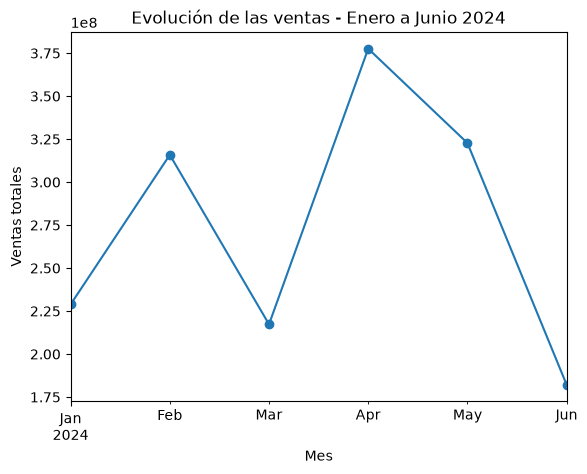

In [13]:

# 1. CONVERTIR LA COLUMNA FECHA A FORMATO DE FECHA

df["fecha"] = pd.to_datetime(df["fecha"])


# 2. CREAR LA COLUMNA VENTA TOTAL

df["venta_total"] = df["precio"] * df["cantidad"]


# 3. FILTRAR DESDE ENERO HASTA JUNIO DE 2024

df_2024 = df[
    (df["fecha"] >= "2024-01-01") &
    (df["fecha"] <= "2024-06-30")
].copy()


# 4. EXTRAER EL MES

df_2024["mes"] = df_2024["fecha"].dt.to_period("M")


# 5. CALCULAR LAS VENTAS MENSUALES

ventas_mensuales = (
    df_2024.groupby("mes")["venta_total"]
    .sum()
)

print("VENTAS MENSUALES")
print(ventas_mensuales)


# 6. CALCULAR LAS UNIDADES VENDIDAS POR MES

unidades_mensuales = (
    df_2024.groupby("mes")["cantidad"]
    .sum()
)

print("\nUNIDADES VENDIDAS")
print(unidades_mensuales)


# 7. CALCULAR EL CRECIMIENTO MES A MES

crecimiento = ventas_mensuales.pct_change() * 100

print("\nCRECIMIENTO MES A MES (%)")
print(crecimiento)


# 8. CREAR TABLA RESUMEN

resumen_mensual = pd.DataFrame({
    "Ventas mensuales": ventas_mensuales,
    "Unidades vendidas": unidades_mensuales,
    "Crecimiento (%)": crecimiento
})

print("\nRESUMEN MENSUAL")
print(resumen_mensual)


# 9. CREAR GRÁFICO DE LÍNEA

ventas_mensuales.plot(
    kind="line",
    marker="o"
)

plt.title("Evolución de las ventas - Enero a Junio 2024")
plt.xlabel("Mes")
plt.ylabel("Ventas totales")

plt.show()